In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [57]:
class HeightData:
    def __init__(self, lowerpath, upperpath, VPPC):
        self.lowerpath = lowerpath
        self.upperpath = upperpath
        self.VPPC = VPPC
        self.loaddata()
    def loaddata(self):
        # Load and parse lowerpath
        lower_raw = np.loadtxt(self.lowerpath, skiprows=4)
        self.lowerdata = {
            'height': lower_raw[:, 0],
            'pixel': lower_raw[:, 1]
        }
        # Load and parse upperpath
        upper_raw = np.loadtxt(self.upperpath, skiprows=4)
        self.upperdata = {
            'height': upper_raw[:, 0],
            'pixel': upper_raw[:, 1]
        }
    def fitgauss(self):
        # Fit Gaussian to lowerdata
        self.lower_params, _ = sp.optimize.curve_fit(
            lambda x, a, mu, sigma: a * np.exp(-(x - mu)**2 / (2 * sigma**2)),
            self.lowerdata['height'], self.lowerdata['pixel'],
            p0=[np.max(self.lowerdata['pixel']), np.mean(self.lowerdata['height']), np.std(self.lowerdata['height'])],
            gtol=0.0001
        )
        # Fit Gaussian to upperdata
        self.upper_params, _ = sp.optimize.curve_fit(
            lambda x, a, mu, sigma: a * np.exp(-(x - mu)**2 / (2 * sigma**2)),
            self.upperdata['height'], self.upperdata['pixel'],
            p0=[np.max(self.upperdata['pixel']), np.mean(self.upperdata['height']), np.std(self.upperdata['height'])],
            gtol=0.0001
        )
        # Calculate difference in means and standard deviations (corrected)
        mean_diff = np.abs(self.lower_params[1] - self.upper_params[1])
        std_diff = np.abs(self.lower_params[2] - self.upper_params[2])
        self.meandiff = {'mean': mean_diff, 'std': std_diff}
        print(f"VPPC: {self.VPPC}, Mean Difference: {mean_diff}, Std Difference: {std_diff}")

    def savefigs(self):
        import os
        # Lower plot
        base_lower, _ = os.path.splitext(self.lowerpath)
        save_path_lower = base_lower + '_fit_lower.png'
        plt.figure(figsize=(6, 6))
        plt.scatter(self.lowerdata['height'], self.lowerdata['pixel'], label='Lower Data')
        plt.plot(self.lowerdata['height'], 
                 self.lower_params[0] * np.exp(-(self.lowerdata['height'] - self.lower_params[1])**2 / (2 * self.lower_params[2]**2)),
                 color='red', label='Lower Fit')
        plt.title('Lower Data Fit')
        plt.xlabel('Height')
        plt.ylabel('Pixel')
        plt.legend()
        plt.tight_layout()
        #print(f"Saving lower figure to: {save_path_lower}")
        #plt.savefig(save_path_lower, dpi=600)
        plt.close()

        # Upper plot
        base_upper, _ = os.path.splitext(self.upperpath)
        save_path_upper = base_upper + '_fit_upper.png'
        plt.figure(figsize=(6, 6))
        plt.scatter(self.upperdata['height'], self.upperdata['pixel'], label='Upper Data')
        plt.plot(self.upperdata['height'], 
                 self.upper_params[0] * np.exp(-(self.upperdata['height'] - self.upper_params[1])**2 / (2 * self.upper_params[2]**2)),
                 color='red', label='Upper Fit')
        plt.title('Upper Data Fit')
        plt.xlabel('Height')
        plt.ylabel('Pixel')
        plt.legend()
        plt.tight_layout()
        #print(f"Saving upper figure to: {save_path_upper}")
        #plt.savefig(save_path_upper, dpi=600)
        plt.close()

    def plotfit(self, savefig=False):
        # Plot lower data and fit
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.scatter(self.lowerdata['height'], self.lowerdata['pixel'], label='Lower Data')
        plt.plot(self.lowerdata['height'], 
                 self.lower_params[0] * np.exp(-(self.lowerdata['height'] - self.lower_params[1])**2 / (2 * self.lower_params[2]**2)),
                 color='red', label='Lower Fit')
        plt.title('Lower Data Fit')
        plt.xlabel('Height')
        plt.ylabel('Pixel')
        plt.legend()
        # Plot upper data and fit
        plt.subplot(1, 2, 2)
        plt.scatter(self.upperdata['height'], self.upperdata['pixel'], label='Upper Data')
        plt.plot(self.upperdata['height'], 
                 self.upper_params[0] * np.exp(-(self.upperdata['height'] - self.upper_params[1])**2 / (2 * self.upper_params[2]**2)),
                 color='red', label='Upper Fit')
        plt.title('Upper Data Fit')
        plt.xlabel('Height')
        plt.ylabel('Pixel')
        plt.legend()
        plt.tight_layout()
        plt.show()

    def process(self):
        self.fitgauss()
        self.plotfit()


In [58]:
PPCDATA = {
    '30_1': HeightData('daten/30_1Hz_Z Height_Forward_004_Lower_Region.txt', 'daten/30_1_1Hz_Z Height_Forward_004_Upper_Region.txt', '30'),
    '30_2': HeightData('daten/30_1Hz_Z Height_Forward_004_Lower_Region.txt', 'daten/30_2_1Hz_Z Height_Forward_004_Upper_Region.txt', '30'),
    '40_1': HeightData('daten/40_1Hz_Z Height_Forward_004_Lower_Region.txt', 'daten/40_1_1Hz_Z Height_Forward_004_Upper_Region.txt', '40'),
    '40_2': HeightData('daten/40_1Hz_Z Height_Forward_004_Lower_Region.txt', 'daten/40_2_1Hz_Z Height_Forward_004_Upper_Region.txt', '40'),
    '50_1': HeightData('daten/50_1Hz_Z Height_Forward_004_Lower_Region.txt', 'daten/50_1_1Hz_Z Height_Forward_004_Upper_Region.txt', '50'),
    '50_2': HeightData('daten/50_1Hz_Z Height_Forward_004_Lower_Region.txt', 'daten/50_2_1Hz_Z Height_Forward_004_Upper_Region.txt', '50'),
}

VPPC: 30, Mean Difference: 5.9239118592413025, Std Difference: 0.3066117620291786


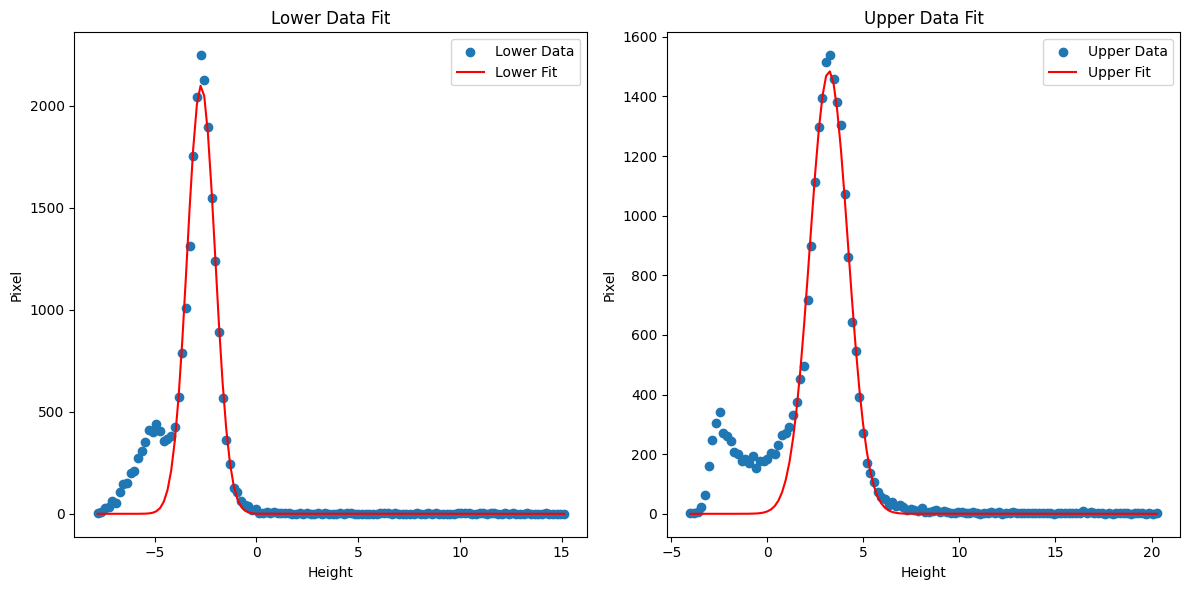

VPPC: 30, Mean Difference: 5.167384062267285, Std Difference: 0.4292975493781469


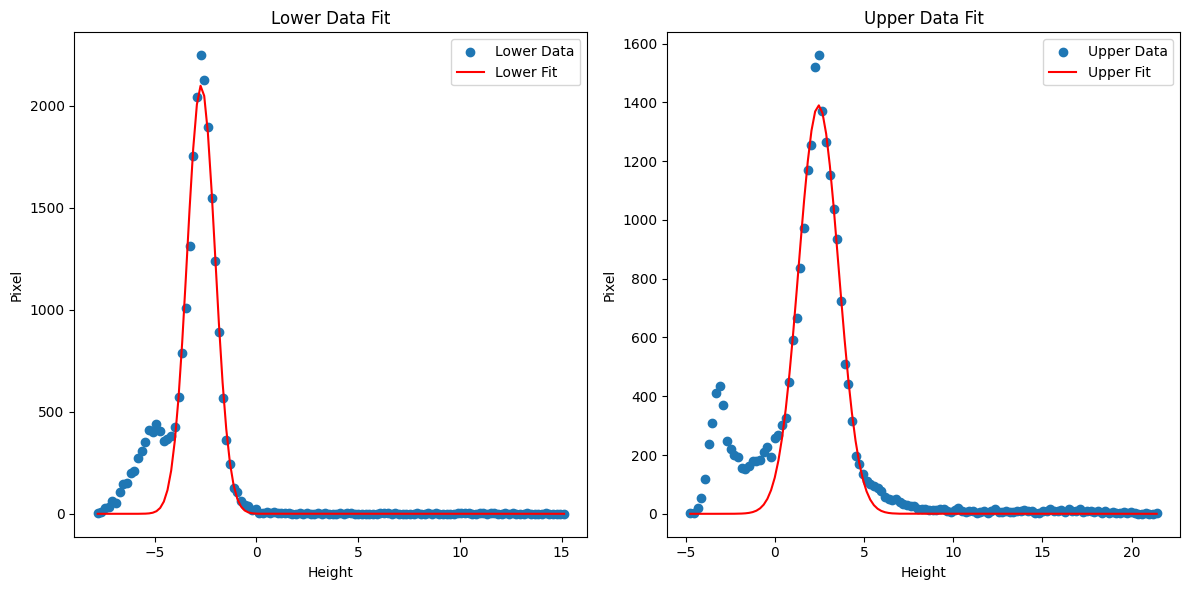

VPPC: 40, Mean Difference: 4.637492907986308, Std Difference: 4.328471182287375


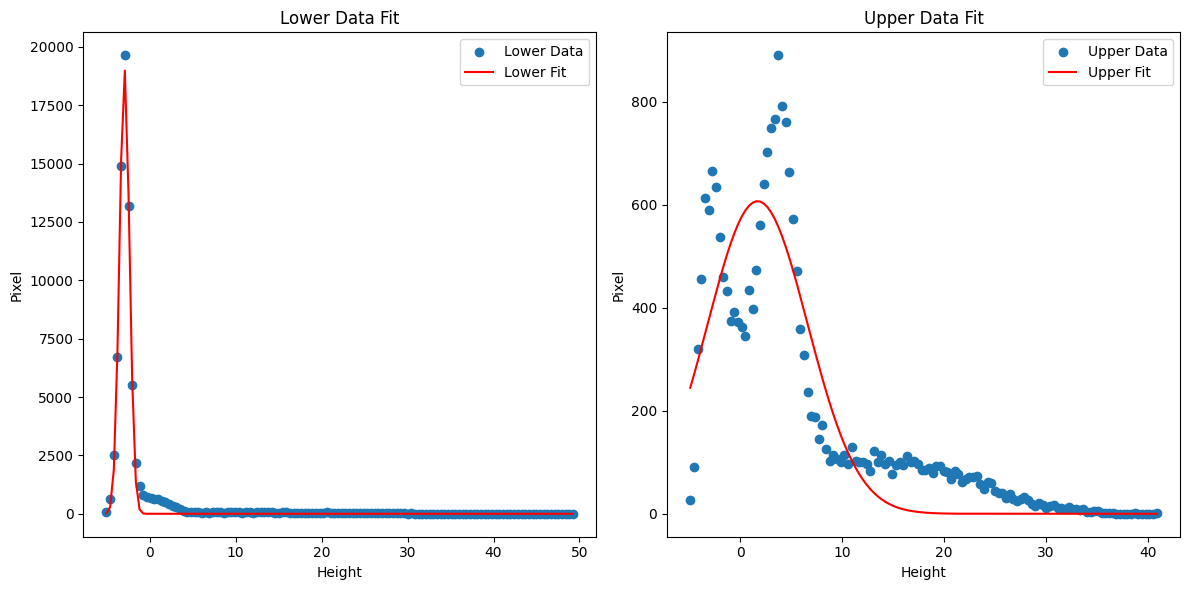

VPPC: 40, Mean Difference: 3.9202077116717087, Std Difference: 3.8385007335007986


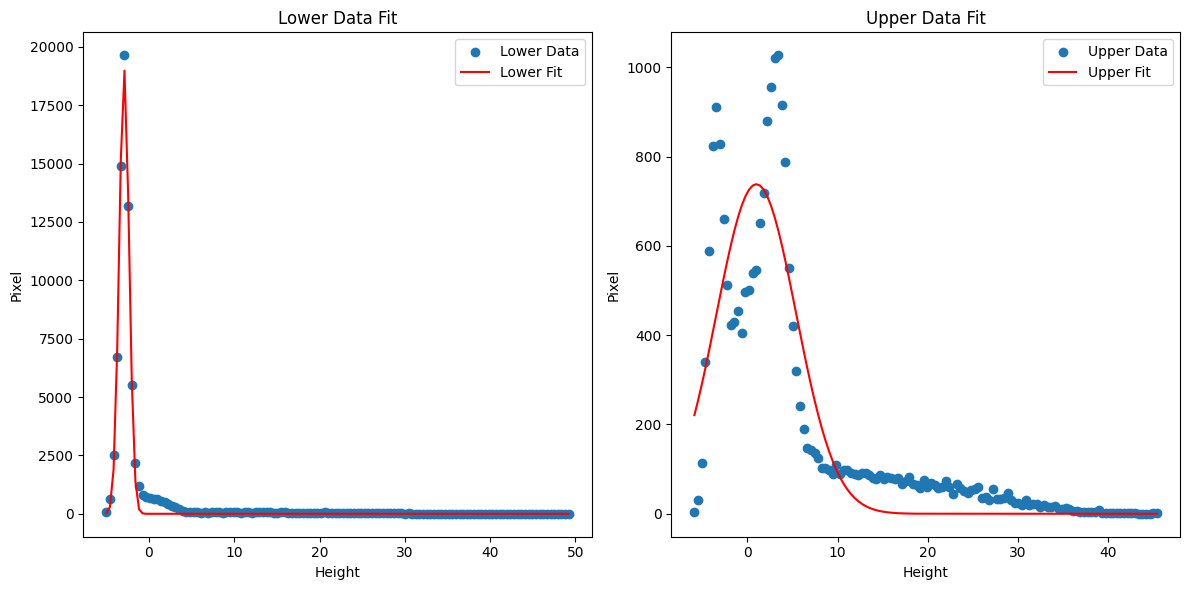

VPPC: 50, Mean Difference: 31.731370018947413, Std Difference: 2.593631881606765


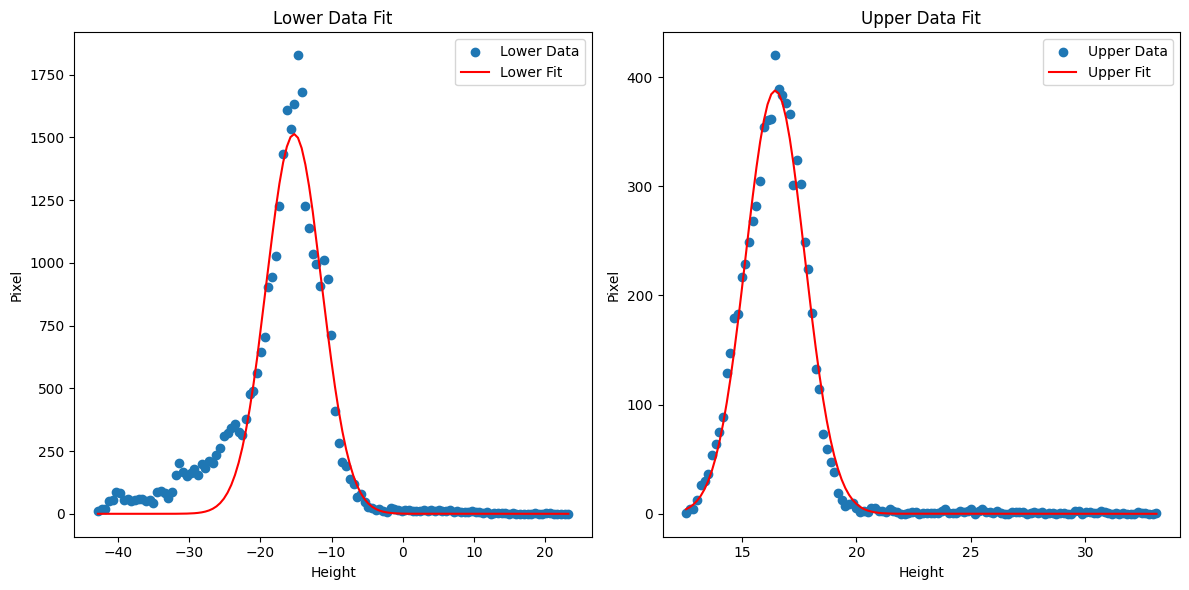

VPPC: 50, Mean Difference: 22.350738446626135, Std Difference: 4.8202686586228305


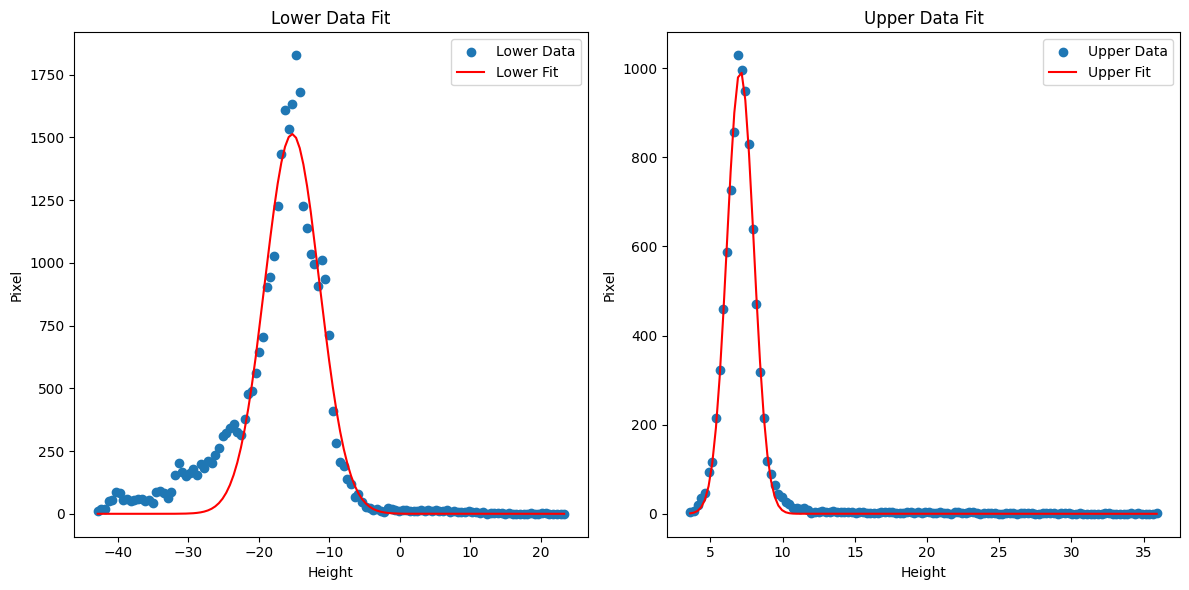

In [59]:
PPCDATA['30_1'].process()
PPCDATA['30_2'].process()
PPCDATA['40_1'].process()
PPCDATA['40_2'].process()
PPCDATA['50_1'].process()
PPCDATA['50_2'].process()

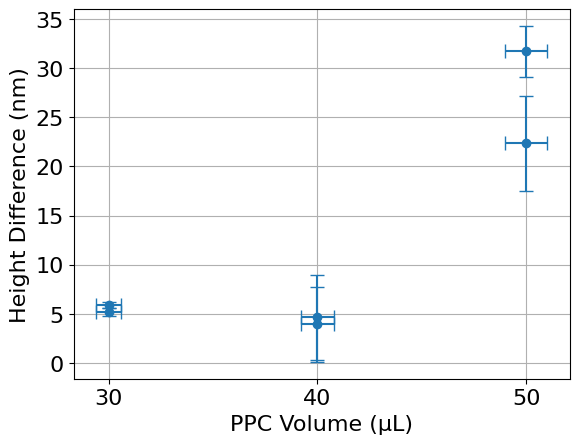

In [61]:
# Plot mean height difference and std difference as error bars against VPPC
import matplotlib.pyplot as plt

VPPCs = []
mean_diffs = []
std_diffs = []
for vppc, hd in PPCDATA.items():
    VPPCs.append(float(hd.VPPC))
    mean_diffs.append(hd.meandiff['mean'])
    std_diffs.append(hd.meandiff['std'])

plt.errorbar(VPPCs, mean_diffs, xerr=np.multiply(0.02, VPPCs), yerr=std_diffs, fmt='o', capsize=5, label='Mean Height')
plt.xlabel('PPC Volume (µL)', fontsize=16)
plt.ylabel('Height Difference (nm)', fontsize=16)
plt.grid(True)
plt.xticks(np.arange(min(VPPCs), max(VPPCs)+1, 10), fontsize=16)
plt.yticks(fontsize=16)
plt.savefig('mean_height.png', dpi=600)
plt.show()